In [25]:
import matplotlib.pyplot as plt

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [31]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [33]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

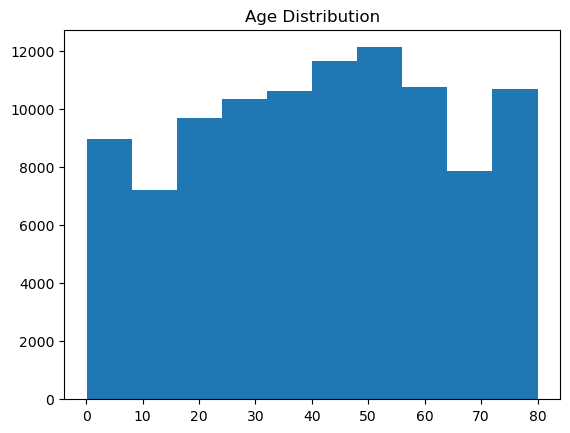

In [35]:
plt.hist(df['age'])
plt.title("Age Distribution")
plt.show()

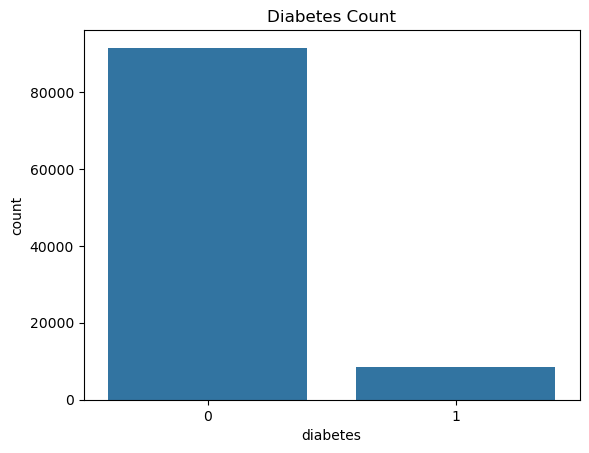

In [37]:
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Count")
plt.show()

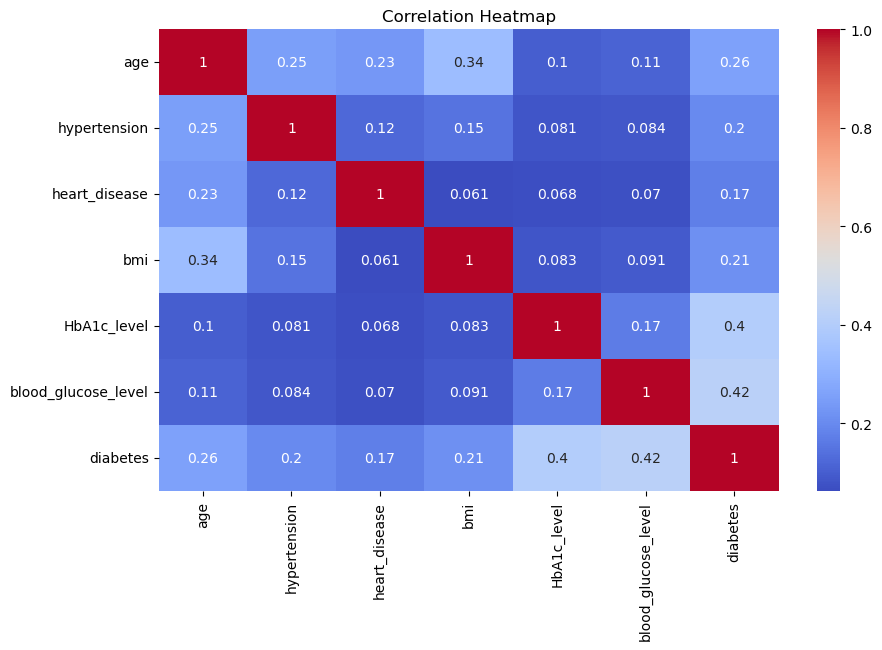

In [39]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [41]:
df['gender'] = df['gender'].map({'Male':0, 'Female':1})
df['smoking_history'] = df['smoking_history'].astype('category').cat.codes

In [43]:
df.drop_duplicates(inplace=True)

In [45]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [47]:
X = X.fillna(0)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred = model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.968538741549662


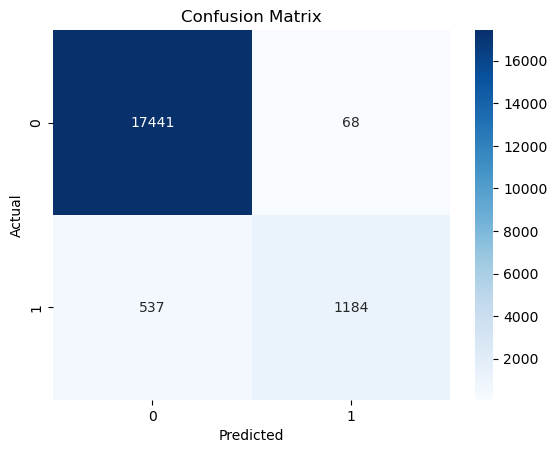

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
import joblib

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [60]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'diabetes.ipynb', 'diabetes_model.pkl', 'diabetes_prediction_dataset.csv', 'diabetes_project.ipynb', 'scaler.pkl']


In [4]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tkinter as tk
from tkinter import ttk
import joblib
import numpy as np

# Load model
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

# Window
root = tk.Tk()
root.title("Diabetes Prediction System")
root.geometry("520x650")
root.configure(bg="#f4f6f7")

title = tk.Label(root, text="Diabetes Prediction",
                 font=("Arial", 18, "bold"), bg="#f4f6f7")
title.pack(pady=10)

frame = tk.Frame(root, bg="white", padx=20, pady=20)
frame.pack(pady=10)

entries = []

# 🔹 Gender Dropdown
tk.Label(frame, text="Gender", bg="white").grid(row=0, column=0, pady=5)
gender = ttk.Combobox(frame, values=["Male", "Female"])
gender.grid(row=0, column=1)
entries.append(gender)

# 🔹 Age
tk.Label(frame, text="Age (1–100)", bg="white").grid(row=1, column=0, pady=5)
age = tk.Entry(frame)
age.grid(row=1, column=1)
entries.append(age)

# 🔹 Hypertension Dropdown
tk.Label(frame, text="Hypertension", bg="white").grid(row=2, column=0, pady=5)
hyper = ttk.Combobox(frame, values=["No", "Yes"])
hyper.grid(row=2, column=1)
entries.append(hyper)

# 🔹 Heart Disease Dropdown
tk.Label(frame, text="Heart Disease", bg="white").grid(row=3, column=0, pady=5)
heart = ttk.Combobox(frame, values=["No", "Yes"])
heart.grid(row=3, column=1)
entries.append(heart)

# 🔹 Smoking
tk.Label(frame, text="Smoking (0–10)", bg="white").grid(row=4, column=0, pady=5)
smoking = tk.Entry(frame)
smoking.grid(row=4, column=1)
entries.append(smoking)

# 🔹 BMI
tk.Label(frame, text="BMI (15–50)", bg="white").grid(row=5, column=0, pady=5)
bmi = tk.Entry(frame)
bmi.grid(row=5, column=1)
entries.append(bmi)

# 🔹 HbA1c
tk.Label(frame, text="HbA1c (4–15)", bg="white").grid(row=6, column=0, pady=5)
hba1c = tk.Entry(frame)
hba1c.grid(row=6, column=1)
entries.append(hba1c)

# 🔹 Glucose
tk.Label(frame, text="Glucose (70–300)", bg="white").grid(row=7, column=0, pady=5)
glucose = tk.Entry(frame)
glucose.grid(row=7, column=1)
entries.append(glucose)

# 🔥 Prediction Function
def predict():
    try:
        values = []

        # Gender
        values.append(0 if entries[0].get() == "Male" else 1)

        # Age
        values.append(float(entries[1].get()))

        # Hypertension
        values.append(1 if entries[2].get() == "Yes" else 0)

        # Heart Disease
        values.append(1 if entries[3].get() == "Yes" else 0)

        # Smoking
        values.append(float(entries[4].get()))

        # BMI
        values.append(float(entries[5].get()))

        # HbA1c
        values.append(float(entries[6].get()))

        # Glucose
        values.append(float(entries[7].get()))

        # Validation
        if not (1 <= values[1] <= 100):
            raise ValueError("Invalid Age")

        if not (15 <= values[5] <= 50):
            raise ValueError("Invalid BMI")

        if not (4 <= values[6] <= 15):
            raise ValueError("Invalid HbA1c")

        if not (70 <= values[7] <= 300):
            raise ValueError("Invalid Glucose")

        data = np.array([values])
        data_scaled = scaler.transform(data)

        result = model.predict(data_scaled)
        prob = model.predict_proba(data_scaled)[0][1] * 100

        if result[0] == 1:
            output.config(text=f"🔴 High Risk ({prob:.2f}%)", fg="red")
        else:
            output.config(text=f"🟢 Low Risk ({prob:.2f}%)", fg="green")

    except Exception as e:
        output.config(text=f"⚠️ Error: {str(e)}", fg="orange")

# Button
btn = tk.Button(root, text="Predict", command=predict,
                bg="#2ecc71", fg="white", font=("Arial", 12), width=15)
btn.pack(pady=15)

# Output
output = tk.Label(root, text="", font=("Arial", 14, "bold"), bg="#f4f6f7")
output.pack()

root.mainloop() 